# Prediction methods

This notebook demonstrates every prediction method in
`nolitisea.prediction`.  Each method operates on 1-D (univariate) or 2-D
`(n_times, n_vars)` series, uses delay-coordinate embedding, and returns
normalised forecast errors (FCE) for comparability across datasets and
scales.

| # | Method | Key functions | Description |
|---|--------|---------------|-------------|
| 1 | Local zeroth-order | `lzo_gm`, `lzo_test`, `lzo_run` | Neighbour-mean forecast |
| 2 | Local linear | `lfo_ar`, `lfo_test`, `lfo_run` | Local linear regression |
| 3 | Polynomial | `fit_polynom`, `polyback` | Global polynomial OLS |
| 4 | RBF | `fit_rbf`, `predict_rbf` | Radial basis function network |
| 5 | ESN | `fit_esn`, `predict_esn` | Echo state network |
| 6 | Neural networks | `fit_nn`, `predict_nn` | MLP, LSTM, GRU, TCN, NARX, Neural ODE, Transformer |
| 7 | Comparison | — | Forecast error across all methods |

## Setup

Imports and test-data generation.

In [1]:
import matplotlib.pyplot as plt
import numpy as np

from nolitisea.prediction import (
    esn_forecast_error,
    fit_esn,
    fit_nn,
    lfo_ar,
    lfo_run,
    lfo_test,
    local_zeroth,
    nn_forecast_error,
    polynomial,
    predict_esn,
    predict_nn,
    rbf,
)

# Access sub-module functions
lzo_gm = local_zeroth.lzo_gm
lzo_test = local_zeroth.lzo_test
lzo_run = local_zeroth.lzo_run
fit_polynom = polynomial.fit_polynom
polyback = polynomial.polyback
fit_rbf = rbf.fit_rbf
predict_rbf = rbf.predict_rbf
rbf_forecast_error = rbf.rbf_forecast_error

## Test Data

We generate three deterministic nonlinear signals commonly used as benchmarks:
- a noisy sine wave (smooth, quasi-periodic)
- the logistic map (chaotic, 1-D map)
- the Henon map (chaotic, 2-D map)

sine shape: (800,)
logistic shape: (800,)
henon_x shape: (800,)


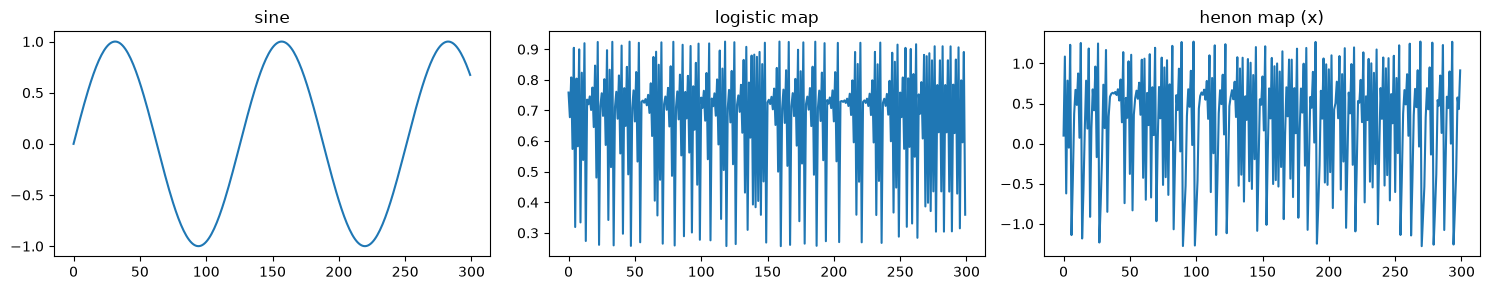

In [2]:
from nolitisea.generate.logistic import logistic as logistic_map


def sine_series(n=800, noise=0.0, seed=0):
    rng = np.random.default_rng(seed)
    t = np.linspace(0, 40, n)
    return np.sin(t) + noise * rng.standard_normal(n)

def henon_map(n=800, a=1.4, b=0.3, x0=0.1, y0=0.1):
    x = np.empty(n)
    y = np.empty(n)
    x[0], y[0] = x0, y0
    for i in range(1, n):
        x[i] = 1 - a * x[i-1]**2 + y[i-1]
        y[i] = b * x[i-1]
    return x, y

sine = sine_series(800)
logistic = logistic_map(n=800)
henon_x, henon_y = henon_map(800)
print(f'sine shape: {sine.shape}')
print(f'logistic shape: {logistic.shape}')
print(f'henon_x shape: {henon_x.shape}')

fig, axes = plt.subplots(1, 3, figsize=(15, 3))
axes[0].plot(sine[:300]); axes[0].set_title('sine')
axes[1].plot(logistic[:300]); axes[1].set_title('logistic map')
axes[2].plot(henon_x[:300]); axes[2].set_title('henon map (x)')
plt.tight_layout()
plt.show()

## 1. `lzo_*` — local zeroth-order prediction

Local zeroth-order prediction predicts the future value as the **mean** of the
neighbours' future values.  Three functions are available:

| Function | Purpose |
|----------|---------|
| `lzo_gm`  | Scan epsilon (neighbourhood size) and record error vs. epsilon |
| `lzo_test` | Adaptive epsilon per reference point -> single error estimate |
| `lzo_run`  | Iterate the model forward to generate a trajectory |

### `lzo_gm` — epsilon scan

Scans a geometric grid of epsilon values and records the average relative
forecast error for each.  Useful for finding the optimal neighbourhood size.

epsilon values: [0.001     0.0012    0.00144   0.001728  0.0020736] ...
best epsilon: 0.0017
best avg_error: 0.0055


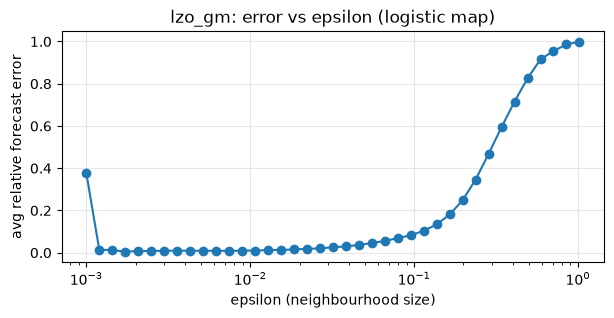

In [3]:
res = lzo_gm(logistic, embed=2, delay=1, step=1,
             eps0=1e-3, eps1=1.0, eps_factor=1.2)

print(f"epsilon values: {res['epsilon'][:5]} ...")
print(f"best epsilon: {res['epsilon'][np.argmin(res['avg_error'])]:.4f}")
print(f"best avg_error: {res['avg_error'].min():.4f}")

plt.figure(figsize=(7, 3))
plt.plot(res['epsilon'], res['avg_error'], 'o-')
plt.xscale('log')
plt.xlabel('epsilon (neighbourhood size)')
plt.ylabel('avg relative forecast error')
plt.title('lzo_gm: error vs epsilon (logistic map)')
plt.grid(True, alpha=0.3)
plt.show()

### `lzo_test` — adaptive per-point error

For each reference point, adaptively expands epsilon until enough neighbours
are found, then reports the forecast error per horizon (`forecast_errors`
has shape `(step, n_vars)`).

In [4]:
res = lzo_test(logistic, embed=2, delay=1, step=1, min_neighbors=30)
print(f"forecast_errors (step x n_vars): {res['forecast_errors']}")
print(f"n_ref_points: {res['n_ref_points']}")

forecast_errors (step x n_vars): [[0.02550108]]
n_ref_points: 798


### `lzo_run` — generate a trajectory

Iterates the local zeroth-order model forward from the end of the series,
producing a forecast trajectory.  The output is in the **original data units**.

status: ok, n_steps_done: 100


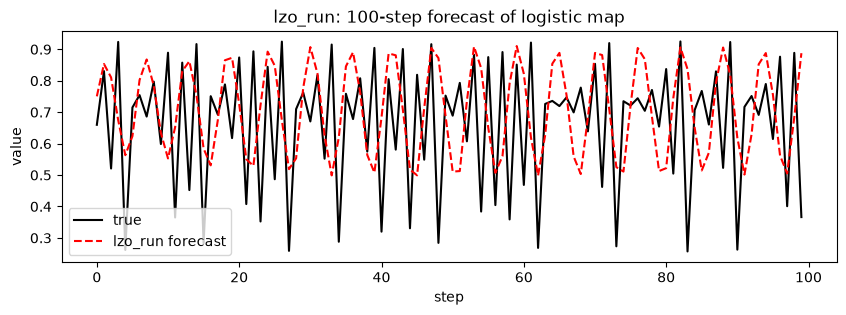

In [5]:
train = logistic[:700]
run = lzo_run(train, embed=2, delay=1, n_steps=100, min_neighbors=30)
print(f"status: {run['status']}, n_steps_done: {run['n_steps_done']}")

traj = run['trajectory']
true = logistic[700:700 + len(traj)]
plt.figure(figsize=(10, 3))
plt.plot(true, 'k-', label='true')
plt.plot(traj, 'r--', label='lzo_run forecast')
plt.xlabel('step')
plt.ylabel('value')
plt.legend()
plt.title('lzo_run: 100-step forecast of logistic map')
plt.show()

## 2. `lfo_*` — local linear prediction

Local linear prediction fits a **local linear regression** on the neighbours
to extrapolate the next value.  Usually more accurate than zeroth-order for
smooth dynamics.

| Function | Purpose |
|----------|---------|
| `lfo_ar`  | Scan epsilon and record error vs. epsilon |
| `lfo_test` | Adaptive epsilon per reference point -> single error estimate |
| `lfo_run`  | Iterate the model forward to generate a trajectory |

### `lfo_ar` — epsilon scan

best epsilon: 0.0012
best avg_error: 0.0000


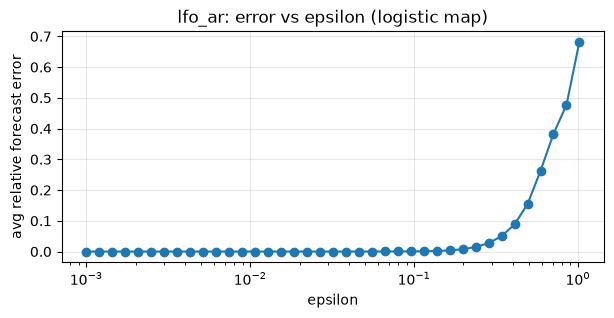

In [6]:
res = lfo_ar(logistic, embed=2, delay=1, step=1,
             eps0=1e-3, eps1=1.0, eps_factor=1.2)

best_idx = np.argmin(res['avg_error'])
print(f"best epsilon: {res['epsilon'][best_idx]:.4f}")
print(f"best avg_error: {res['avg_error'][best_idx]:.4f}")

plt.figure(figsize=(7, 3))
plt.plot(res['epsilon'], res['avg_error'], 'o-')
plt.xscale('log')
plt.xlabel('epsilon')
plt.ylabel('avg relative forecast error')
plt.title('lfo_ar: error vs epsilon (logistic map)')
plt.grid(True, alpha=0.3)
plt.show()

### `lfo_test` — adaptive per-point error

In [7]:
res = lfo_test(logistic, embed=2, delay=1, step=1, min_neighbors=30)
print(f"avg_error: {res['avg_error']:.4f}")
print(f"final_epsilon: {res['final_epsilon']:.4f}")
print(f"n_done / n_total: {res['n_done']}/{res['n_total']}")

avg_error: 0.0001
final_epsilon: 0.0662
n_done / n_total: 798/798


### `lfo_run` — generate a trajectory

`method='linear'` (default) fits a local linear model; `method='zeroth'`
uses the neighbour mean.

status: escaped, n_steps_done: 2


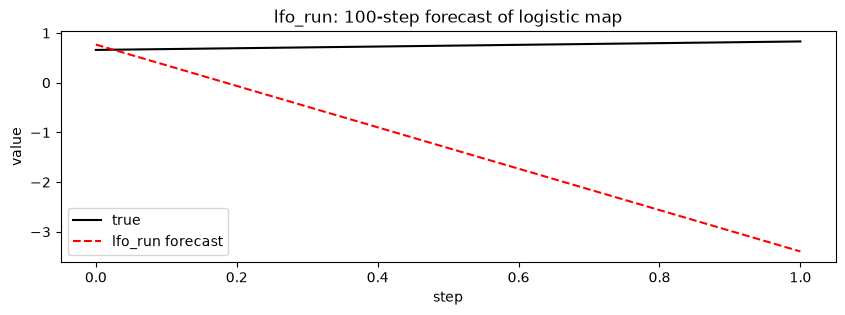

In [8]:
train = logistic[:700]
run = lfo_run(train, embed=2, delay=1, n_steps=100,
              method='linear', min_neighbors=30)
print(f"status: {run['status']}, n_steps_done: {run['n_steps_done']}")

traj = run['trajectory']
true = logistic[700:700 + len(traj)]
plt.figure(figsize=(10, 3))
plt.plot(true, 'k-', label='true')
plt.plot(traj, 'r--', label='lfo_run forecast')
plt.xlabel('step')
plt.ylabel('value')
plt.legend()
plt.title('lfo_run: 100-step forecast of logistic map')
plt.show()

### Multivariate local linear

Both `lfo_*` and `lzo_*` accept 2-D input `(n_times, n_vars)`.  Here we use
both coordinates of the Henon map as a 2-component series.

In [9]:
henon_2d = np.column_stack([henon_x, henon_y])
res = lfo_test(henon_2d, embed=2, delay=1, step=1, min_neighbors=30)
print(f"avg_error: {res['avg_error']:.4f}")
print(f"per-component errors: {res['comp_errors']}")

avg_error: 0.0046
per-component errors: [9.23653817e-03 3.24254632e-16]


## 3. `fit_polynom` — polynomial prediction

`fit_polynom` fits a global polynomial model of degree `degree` on the delay
embedding by ordinary least squares.  `polyback` performs greedy
backward-elimination of monomial terms to improve generalisation.

### `fit_polynom` — full polynomial fit

In [10]:
model = fit_polynom(logistic, dim=2, delay=1, degree=2, step=1)
print(f"terms: {model['terms']}")
print(f"coeffs: {model['coeffs']}")
print(f"in_sample_rmse: {model['in_sample_rmse']:.6f}")

terms: [(0, 0), (1, 0), (2, 0), (0, 1), (1, 1), (0, 2)]
coeffs: [-4.67991597e-12  2.71242675e+00 -3.70000000e+00  3.65402103e+00
 -5.68981211e-12 -3.65402103e+00]
in_sample_rmse: 0.000000


### `polyback` — backward elimination

Starts from the full polynomial and greedily removes the monomial whose
removal most improves the (out-of-sample) error, down to `down_to` terms.

In [11]:
train = logistic[:600]
test = logistic[600:]
pb = polyback(train, dim=2, delay=1, degree=3, down_to=2, step=1,
              insample=400)
print(f"final terms: {pb['final']['terms']}")
print(f"final in_sample_rmse: {pb['final']['in_sample_rmse']:.6f}")
print(f"final out_of_sample_rmse: {pb['final']['out_of_sample_rmse']:.6f}")
print(f"decision based on: {pb['decision_error']}")

final terms: [(1, 0), (2, 0)]
final in_sample_rmse: 0.000000
final out_of_sample_rmse: 0.000000
decision based on: out_of_sample


### Iterated forecast with `cast_steps`

casted shape: (50,)


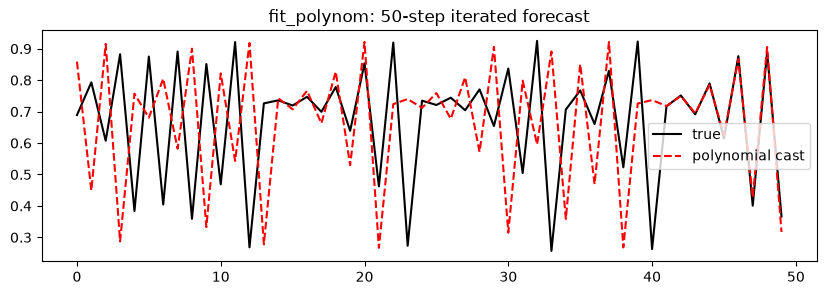

In [12]:
model = fit_polynom(logistic, dim=2, delay=1, degree=2, step=1,
                    cast_steps=50)
casted = model['casted']
true = logistic[-50:]
print(f"casted shape: {casted.shape}")

plt.figure(figsize=(10, 3))
plt.plot(true, 'k-', label='true')
plt.plot(casted, 'r--', label='polynomial cast')
plt.legend()
plt.title('fit_polynom: 50-step iterated forecast')
plt.show()

## 4. `fit_rbf` — RBF prediction

`fit_rbf` fits a radial-basis-function network: Gaussian kernels centred on
a subset of delay vectors, with a linear readout trained by OLS.  Width
`eps` defaults to the average centre spacing.

### `fit_rbf` and `predict_rbf`

eps: 0.5110
in_sample_fce: 0.0001


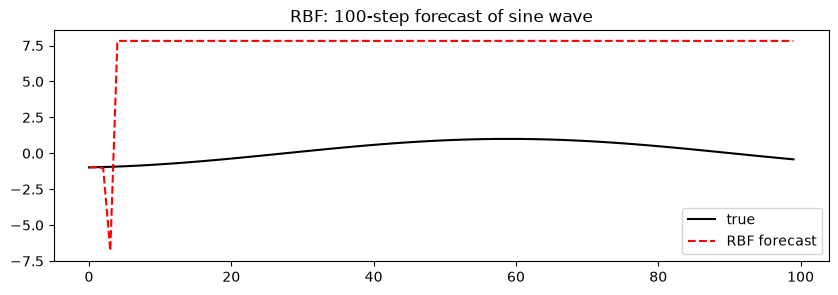

In [13]:
train = sine[:600]
model = fit_rbf(train, dim=3, delay=1, n_centers=50, step=1)
print(f"eps: {model['eps']:.4f}")
print(f"in_sample_fce: {model['in_sample_fce']:.4f}")

fc = predict_rbf(model, train, n_steps=100)
true = sine[600:700]
plt.figure(figsize=(10, 3))
plt.plot(true, 'k-', label='true')
plt.plot(fc, 'r--', label='RBF forecast')
plt.legend()
plt.title('RBF: 100-step forecast of sine wave')
plt.show()

### Out-of-sample split via `insample`

In [14]:
model = fit_rbf(sine, dim=3, delay=1, n_centers=50, step=1, insample=600)
print(f"in_sample_fce:  {model['in_sample_fce']:.4f}")
print(f"out_of_sample_fce: {model['out_of_sample_fce']:.4f}")

in_sample_fce:  0.0000
out_of_sample_fce: 0.0000


## 5. `fit_esn` — echo state network

The ESN uses a **fixed random reservoir** with a trained linear readout
(ridge regression).  No backpropagation needed - training is a single
matrix solve.  Pure NumPy, no external dependencies.

### `fit_esn` and `predict_esn`

in_sample_fce: 0.0000


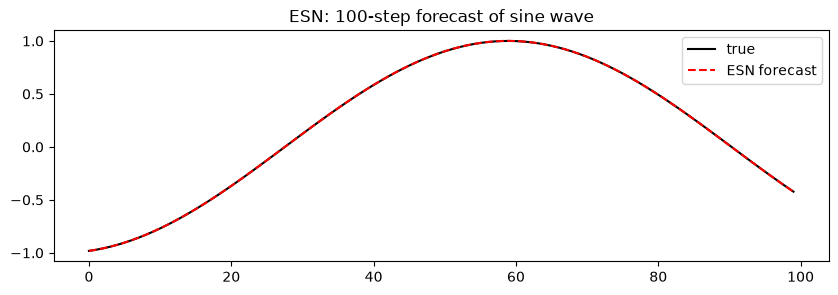

In [15]:
train = sine[:600]
model = fit_esn(train, dim=3, delay=1, n_reservoir=200,
                spectral_radius=0.9, seed=42)
print(f"in_sample_fce: {model['in_sample_fce']:.4f}")

fc = predict_esn(model, train, n_steps=100)
true = sine[600:700]
plt.figure(figsize=(10, 3))
plt.plot(true, 'k-', label='true')
plt.plot(fc, 'r--', label='ESN forecast')
plt.legend()
plt.title('ESN: 100-step forecast of sine wave')
plt.show()

### Multivariate ESN

n_vars: 2
in_sample_fce: 0.0028


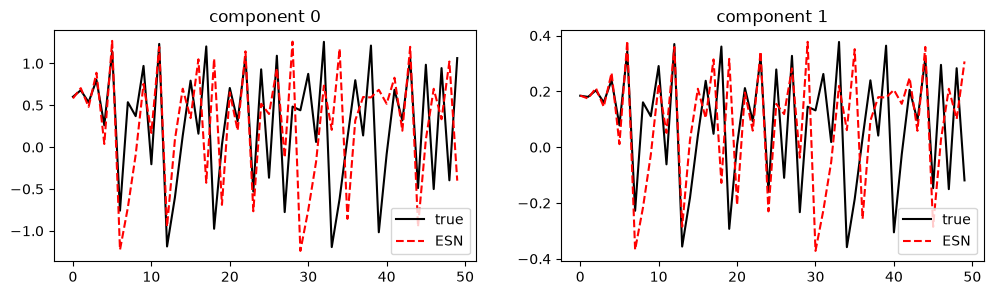

In [16]:
henon_2d = np.column_stack([henon_x, henon_y])
train = henon_2d[:600]
model = fit_esn(train, dim=3, delay=1, n_reservoir=300, seed=42)
print(f"n_vars: {model['n_vars']}")
print(f"in_sample_fce: {model['in_sample_fce']:.4f}")

fc = predict_esn(model, train, n_steps=50)
true = henon_2d[600:650]
fig, axes = plt.subplots(1, 2, figsize=(12, 3))
for c in range(2):
    axes[c].plot(true[:, c], 'k-', label='true')
    axes[c].plot(fc[:, c], 'r--', label='ESN')
    axes[c].set_title(f'component {c}')
    axes[c].legend()
plt.show()

### `esn_forecast_error` — evaluate on a sub-interval

`esn_forecast_error(series, model, dim, delay, step, i0, i1)` computes the
one-step RMSE over the index range `[i0, i1)`.  The input `series` must be
**rescaled** to `[0, 1]` (matching the model's internal scaling).  Use
`rescale_data` for this.  This is useful for out-of-sample evaluation on a
hold-out window without re-fitting.

In [17]:
from nolitisea.utils.rescale import rescale_data

train = sine[:600]
model = fit_esn(train, dim=3, delay=1, n_reservoir=200, seed=42)

# Rescale the *full* series with the SAME (minv, interval) used by the model
s_resc, minv, interval = rescale_data(sine)

# In-sample error over [0, 600)
err_in = esn_forecast_error(s_resc, model, dim=3, delay=1, step=1,
                             i0=0, i1=600)
# Out-of-sample error over [600, 800)
err_out = esn_forecast_error(s_resc, model, dim=3, delay=1, step=1,
                              i0=600, i1=800)

print(f"in-sample RMSE  [0, 600):   {err_in:.6f}")
print(f"out-of-sample RMSE [600, 800): {err_out:.6f}")
print(f"ratio (out/in): {err_out / err_in:.2f}")

in-sample RMSE  [0, 600):   0.000005
out-of-sample RMSE [600, 800): 0.000825
ratio (out/in): 172.23


## 6. `fit_nn` — neural network prediction

`fit_nn` provides **seven** neural-network architectures via the
`model_type` parameter.  All use PyTorch (lazy import - the module loads
without torch, but `fit_nn` requires it).

| `model_type` | Architecture |
|--------------|-------------|
| `"mlp"`       | Feedforward MLP on flat delay vectors |
| `"lstm"`      | Long short-term memory RNN |
| `"gru"`       | Gated recurrent unit RNN |
| `"tcn"`       | Temporal convolutional network (causal dilated convs) |
| `"narx"`      | Nonlinear autoregressive (MLP backbone) |
| `"node"`      | Neural ODE (learns vector field, Euler integration) |
| `"transformer"` | Transformer encoder + linear head |

### MLP

in_sample_fce: 0.1039


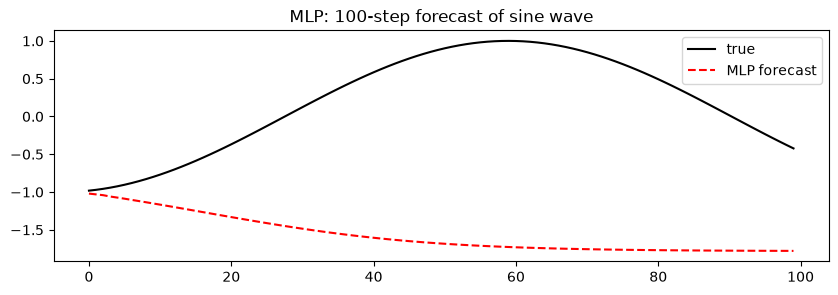

In [18]:
train = sine[:600]
model = fit_nn(train, model_type='mlp', dim=3, hidden_layers=(32, 32),
               epochs=300, seed=42)
print(f"in_sample_fce: {model['in_sample_fce']:.4f}")

fc = predict_nn(model, train, n_steps=100)
true = sine[600:700]
plt.figure(figsize=(10, 3))
plt.plot(true, 'k-', label='true')
plt.plot(fc, 'r--', label='MLP forecast')
plt.legend()
plt.title('MLP: 100-step forecast of sine wave')
plt.show()

### LSTM

in_sample_fce:  0.1088
out_of_sample_fce: 0.1165


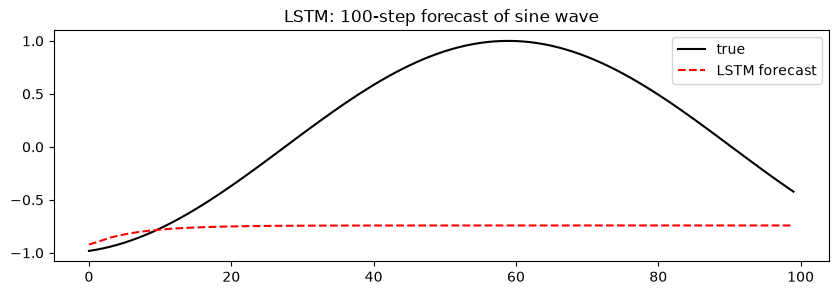

In [19]:
model = fit_nn(sine, model_type='lstm', dim=3, hidden_layers=(32,),
               epochs=200, insample=600, seed=42)
print(f"in_sample_fce:  {model['in_sample_fce']:.4f}")
print(f"out_of_sample_fce: {model['out_of_sample_fce']:.4f}")

fc = predict_nn(model, sine[:600], n_steps=100)
true = sine[600:700]
plt.figure(figsize=(10, 3))
plt.plot(true, 'k-', label='true')
plt.plot(fc, 'r--', label='LSTM forecast')
plt.legend()
plt.title('LSTM: 100-step forecast of sine wave')
plt.show()

### GRU

in_sample_fce:  0.1013
out_of_sample_fce: 0.1057


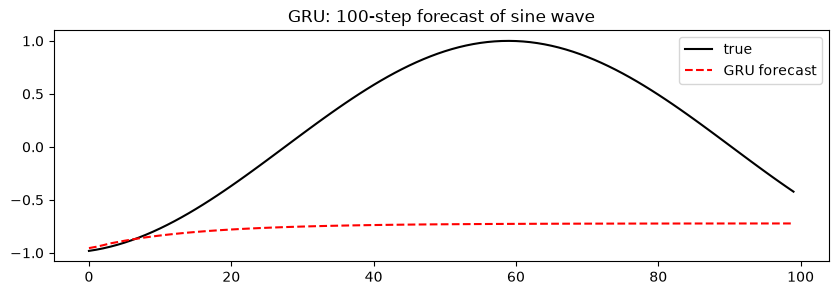

In [20]:
model = fit_nn(sine, model_type='gru', dim=3, hidden_layers=(32,),
               epochs=200, insample=600, seed=42)
print(f"in_sample_fce:  {model['in_sample_fce']:.4f}")
print(f"out_of_sample_fce: {model['out_of_sample_fce']:.4f}")

fc = predict_nn(model, sine[:600], n_steps=100)
true = sine[600:700]
plt.figure(figsize=(10, 3))
plt.plot(true, 'k-', label='true')
plt.plot(fc, 'r--', label='GRU forecast')
plt.legend()
plt.title('GRU: 100-step forecast of sine wave')
plt.show()

### TCN (temporal convolutional network)

In [ ]:
model = fit_nn(sine, model_type='tcn', dim=3, hidden_layers=(32,),
               epochs=200, insample=600, seed=42)
print(f"in_sample_fce:  {model['in_sample_fce']:.4f}")
print(f"out_of_sample_fce: {model['out_of_sample_fce']:.4f}")

fc = predict_nn(model, sine[:600], n_steps=100)
true = sine[600:700]
plt.figure(figsize=(10, 3))
plt.plot(true, 'k-', label='true')
plt.plot(fc, 'r--', label='TCN forecast')
plt.legend()
plt.title('TCN: 100-step forecast of sine wave')
plt.show()

### NARX

in_sample_fce:  0.1140
out_of_sample_fce: 0.1518


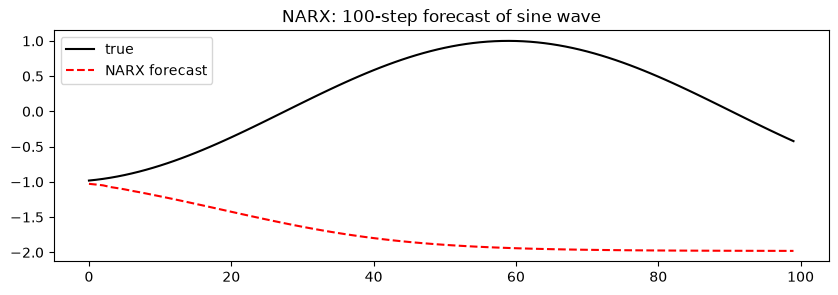

In [ ]:
model = fit_nn(sine, model_type='narx', dim=3, hidden_layers=(32, 32),
               epochs=200, insample=600, seed=42)
print(f"in_sample_fce:  {model['in_sample_fce']:.4f}")
print(f"out_of_sample_fce: {model['out_of_sample_fce']:.4f}")

fc = predict_nn(model, sine[:600], n_steps=100)
true = sine[600:700]
plt.figure(figsize=(10, 3))
plt.plot(true, 'k-', label='true')
plt.plot(fc, 'r--', label='NARX forecast')
plt.legend()
plt.title('NARX: 100-step forecast of sine wave')
plt.show()

### Neural ODE

in_sample_fce:  0.3713
out_of_sample_fce: 0.3685


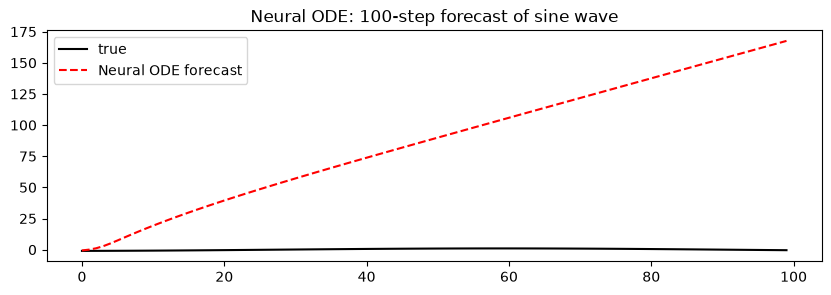

In [ ]:
model = fit_nn(sine, model_type='node', dim=3, hidden_layers=(32,),
               epochs=200, insample=600, seed=42)
print(f"in_sample_fce:  {model['in_sample_fce']:.4f}")
print(f"out_of_sample_fce: {model['out_of_sample_fce']:.4f}")

fc = predict_nn(model, sine[:600], n_steps=100)
true = sine[600:700]
plt.figure(figsize=(10, 3))
plt.plot(true, 'k-', label='true')
plt.plot(fc, 'r--', label='Neural ODE forecast')
plt.legend()
plt.title('Neural ODE: 100-step forecast of sine wave')
plt.show()

### Transformer

in_sample_fce:  0.1289
out_of_sample_fce: 0.1528


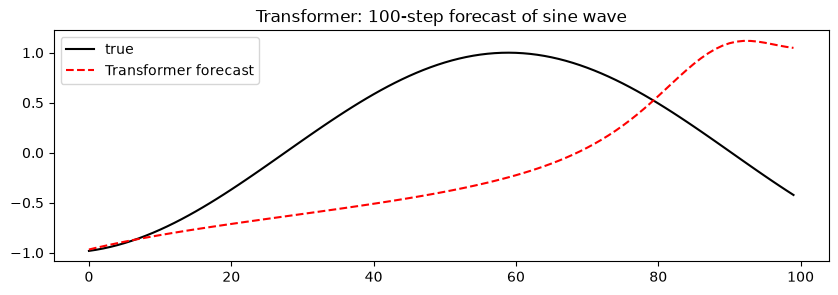

In [ ]:
model = fit_nn(sine, model_type='transformer', dim=3, hidden_layers=(32,),
               epochs=200, insample=600, n_heads=4, n_layers=2, seed=42)
print(f"in_sample_fce:  {model['in_sample_fce']:.4f}")
print(f"out_of_sample_fce: {model['out_of_sample_fce']:.4f}")

fc = predict_nn(model, sine[:600], n_steps=100)
true = sine[600:700]
plt.figure(figsize=(10, 3))
plt.plot(true, 'k-', label='true')
plt.plot(fc, 'r--', label='Transformer forecast')
plt.legend()
plt.title('Transformer: 100-step forecast of sine wave')
plt.show()

### `nn_forecast_error` — evaluate on a sub-interval

`nn_forecast_error(series, model, dim, delay, step, i0, i1)` is the neural-net
analogue of `esn_forecast_error`.  The input `series` must be **rescaled** to
`[0, 1]`.  It rebuilds the network from the model's saved weights and computes
the one-step RMSE over `[i0, i1)`.

In [ ]:
from nolitisea.utils.rescale import rescale_data

train = sine[:600]
model = fit_nn(train, model_type='mlp', dim=3, hidden_layers=(32, 32),
               epochs=300, insample=600, seed=42)

# Rescale the full series with the same (minv, interval) as the model
s_resc, minv, interval = rescale_data(sine)

err_in = nn_forecast_error(s_resc, model, dim=3, delay=1, step=1,
                            i0=0, i1=600)
err_out = nn_forecast_error(s_resc, model, dim=3, delay=1, step=1,
                             i0=600, i1=800)

print(f"in-sample RMSE  [0, 600):   {err_in:.6f}")
print(f"out-of-sample RMSE [600, 800): {err_out:.6f}")
print(f"ratio (out/in): {err_out / err_in:.2f}")

in-sample RMSE  [0, 600):   0.036824
out-of-sample RMSE [600, 800): 0.034960
ratio (out/in): 0.95


## 7. Comparison — forecast error across methods

Below we compare the one-step-ahead normalised forecast error (FCE) of all
methods on the logistic map.  Lower is better.

lzo_test      FCE = 0.0255
lfo_test      FCE = 0.0001
polynomial    FCE = 0.0000
rbf           FCE = 0.0000
esn           FCE = 1.8462
mlp           FCE = 1.5864


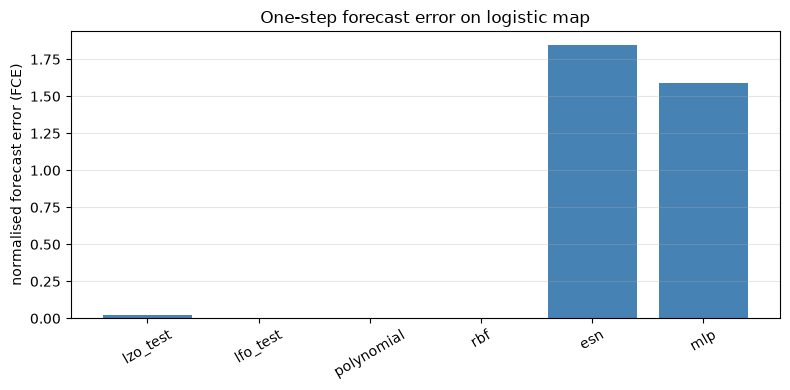

In [ ]:
series = logistic
dim, delay, step = 2, 1, 1
insample = 600

results = {}

# local zeroth-order
r = lzo_test(series, embed=dim, delay=delay, step=step, min_neighbors=30)
results['lzo_test'] = float(r['forecast_errors'][0, 0])

# local linear
r = lfo_test(series, embed=dim, delay=delay, step=step, min_neighbors=30)
results['lfo_test'] = r['avg_error']

# polynomial
m = fit_polynom(series, dim=dim, delay=delay, degree=3, step=step,
                insample=insample)
results['polynomial'] = m['out_of_sample_rmse'] / np.std(series[insample:])

# RBF
m = fit_rbf(series, dim=dim, delay=delay, n_centers=50, step=step,
            insample=insample)
results['rbf'] = m['out_of_sample_fce']

# ESN
m = fit_esn(series, dim=dim, delay=delay, n_reservoir=200, step=step,
            insample=insample, seed=42)
results['esn'] = m['out_of_sample_fce']

# MLP
m = fit_nn(series, model_type='mlp', dim=dim, delay=delay, step=step,
           hidden_layers=(32, 32), epochs=300, insample=insample, seed=42)
results['mlp'] = m['out_of_sample_fce']

for name, err in results.items():
    print(f'{name:12s}  FCE = {err:.4f}')

plt.figure(figsize=(8, 4))
names = list(results.keys())
vals = list(results.values())
plt.bar(names, vals, color='steelblue')
plt.ylabel('normalised forecast error (FCE)')
plt.title('One-step forecast error on logistic map')
plt.xticks(rotation=30)
plt.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## Summary

The `nolitisea.prediction` module provides a spectrum of forecasting methods
ranging from simple local models to deep neural networks:

| Method | Strengths | Best for |
|--------|----------|----------|
| `lzo_*` | Simple, robust | Baseline, quick scans |
| `lfo_*` | Accurate on smooth dynamics | Most nonlinear series |
| `fit_polynom` | Interpretable, fast | Low-dimensional smooth maps |
| `fit_rbf` | Flexible, few hyperparams | Moderate-dimensional data |
| `fit_esn` | Very fast training, good memory | Chaotic, long-memory series |
| `fit_nn` | Expressive, many architectures | Complex patterns, large data |

All methods return normalised forecast errors (FCE = RMSE / std) for
comparability across datasets and scales.